# Forest Fires Capstone — Exploratory Data Analysis

## Project Question
Can weather conditions, fire-weather indices, location, and seasonal patterns help explain or predict the burned area of forest fires?

In [20]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# Load the raw dataset

df = pd.read_csv("../data/raw/forestfires.csv")
df.head()


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [22]:
# Check the size of the dataset

df.shape

(517, 13)

The dataset contains 517 forest fire observations and 13 variables.

In [23]:
# Understand the columns

df.info()

df.columns

<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    str    
 3   day     517 non-null    str    
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), str(2)
memory usage: 52.6 KB


Index(['X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH',
       'wind', 'rain', 'area'],
      dtype='str')

## Dataset Features

- X, Y: Spatial coordinates
- month: Month of the fire
- day: Day of the week
- FFMC: Fine Fuel Moisture Code
- DMC: Duff Moisture Code
- DC: Drought Code
- ISI: Initial Spread Index
- temp: Temperature in Celsius
- RH: Relative humidity
- wind: Wind speed
- rain: Rainfall
- area: Burned area in hectares

In [24]:
# summary statistics

df.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


This helps to understand the range, average, minimum and maximum of the numerical variables.

In [25]:
df.describe(include="all")

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517,517,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
unique,NaN,NaN,12,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,aug,sun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,184,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4.669246,4.299807,NaN,NaN,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,NaN,NaN,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,NaN,NaN,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,NaN,NaN,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,NaN,NaN,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,NaN,NaN,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000


This includes month and day.

In [26]:
# Check for missing values

df.isnull().sum()


X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64


The dataset contains no missing values.

In [27]:
# Check duplicates

df.duplicated().sum()

np.int64(4)

The dataset contains duplicate.

In [28]:
# Examine the target variable area

df["area"].describe()

count     517.000000
mean       12.847292
std        63.655818
min         0.000000
25%         0.000000
50%         0.520000
75%         6.570000
max      1090.840000
Name: area, dtype: float64

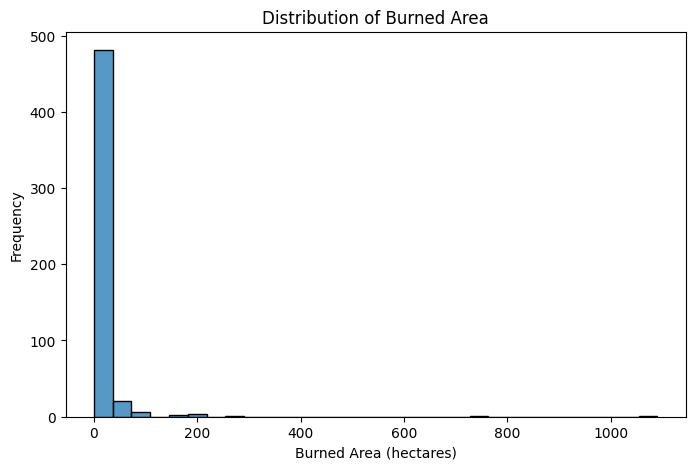

In [29]:
# histogram:

plt.figure(figsize=(8, 5))

sns.histplot(df["area"], bins=30)

plt.title("Distribution of Burned Area")
plt.xlabel("Burned Area (hectares)")
plt.ylabel("Frequency")

plt.show()



The burned-area variable is highly right-skewed. Most recorded fires burned relatively small areas, while a small number of fires resulted in much larger burned areas.


In [30]:
#Check how many fires have area = 0
(df["area"] == 0).sum()


np.int64(247)

In [31]:
(df["area"] == 0).mean() * 100

np.float64(47.77562862669246)

In [32]:
df["area"].value_counts().head(10)

area
0.00    247
1.94      3
0.43      2
0.90      2
1.46      2
1.56      2
1.63      2
1.64      2
1.75      2
1.95      2
Name: count, dtype: int64

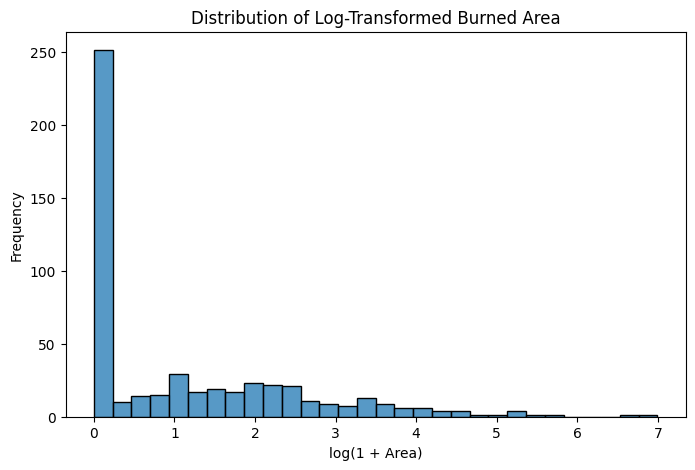

In [34]:
# Create a log version of area for exploration

df["log_area"] = np.log1p(df["area"])

plt.figure(figsize=(8, 5))

sns.histplot(df["log_area"], bins=30)

plt.title("Distribution of Log-Transformed Burned Area")
plt.xlabel("log(1 + Area)")
plt.ylabel("Frequency")

plt.show()

Because burned area is strongly skewed, a log transformation reduces the influence of extremely large fires and may be more appropriate for regression modeling.

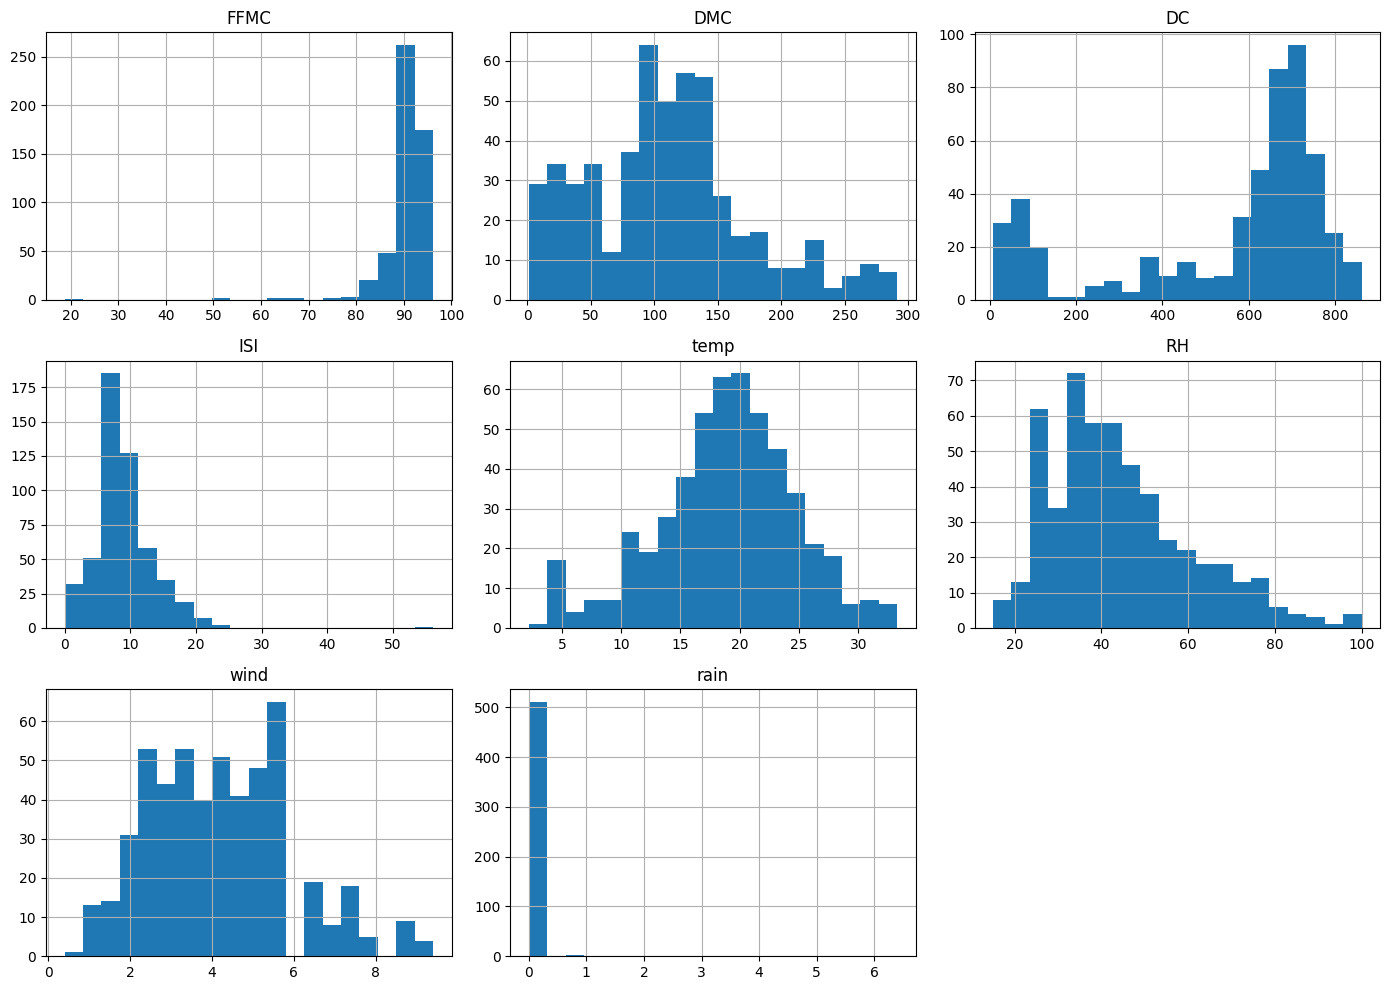

In [36]:
# Look at the numerical variable distributions

numeric_cols = [
    "FFMC",
    "DMC",
    "DC",
    "ISI",
    "temp",
    "RH",
    "wind",
    "rain"
]

df[numeric_cols].hist(figsize=(14, 10), bins=20)

plt.tight_layout()

plt.show()

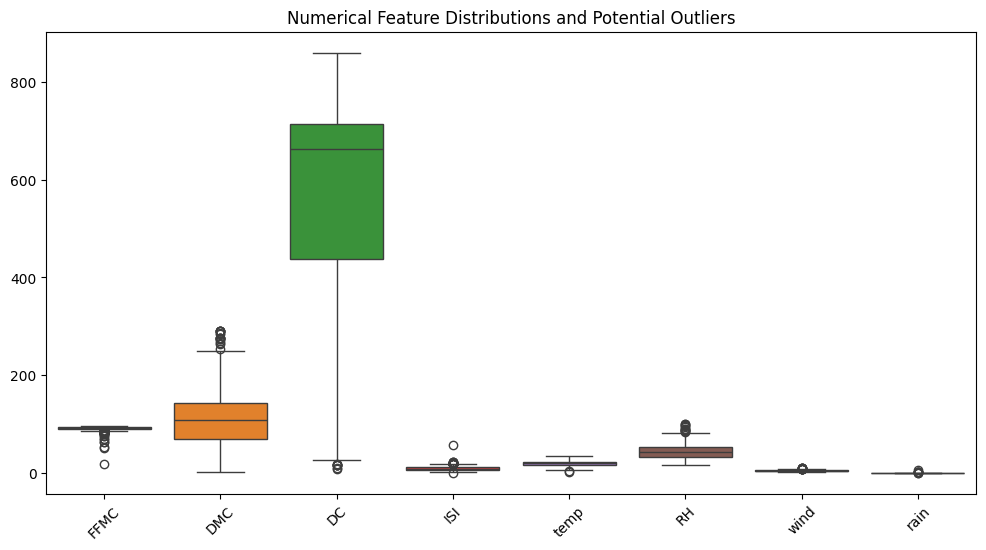

In [37]:
#Check outliers

plt.figure(figsize=(12, 6))

sns.boxplot(data=df[numeric_cols])

plt.xticks(rotation=45)
plt.title("Numerical Feature Distributions and Potential Outliers")

plt.show()

In [38]:
#Explore fires by month

month_counts = df["month"].value_counts()

month_counts

month
aug    184
sep    172
mar     54
jul     32
feb     20
jun     17
oct     15
apr      9
dec      9
jan      2
may      2
nov      1
Name: count, dtype: int64

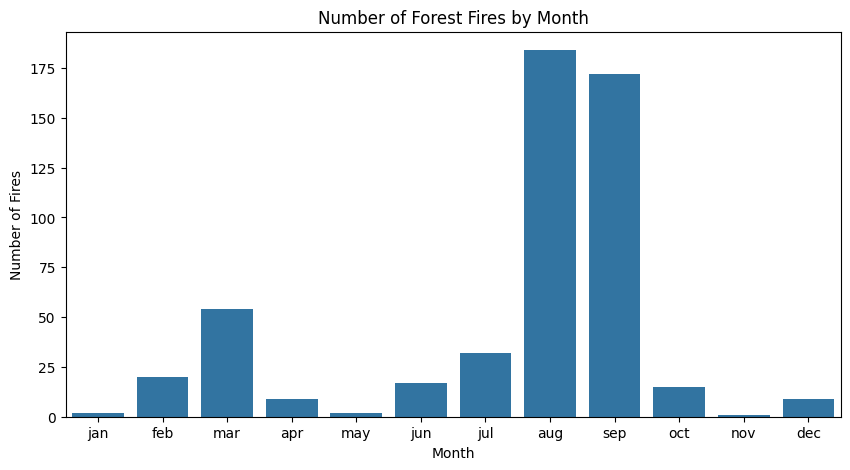

In [40]:
month_order = [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec"
]
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="month",
    order=month_order
)

plt.title("Number of Forest Fires by Month")
plt.xlabel("Month")
plt.ylabel("Number of Fires")

plt.show()

In [41]:
#Burned area by month

monthly_area = (
    df.groupby("month")["area"]
    .sum()
    .reindex(month_order)
)

monthly_area


month
jan       0.00
feb     125.50
mar     235.26
apr      80.02
may      38.48
jun      99.30
jul     459.83
aug    2297.99
sep    3086.13
oct      99.57
nov       0.00
dec     119.97
Name: area, dtype: float64

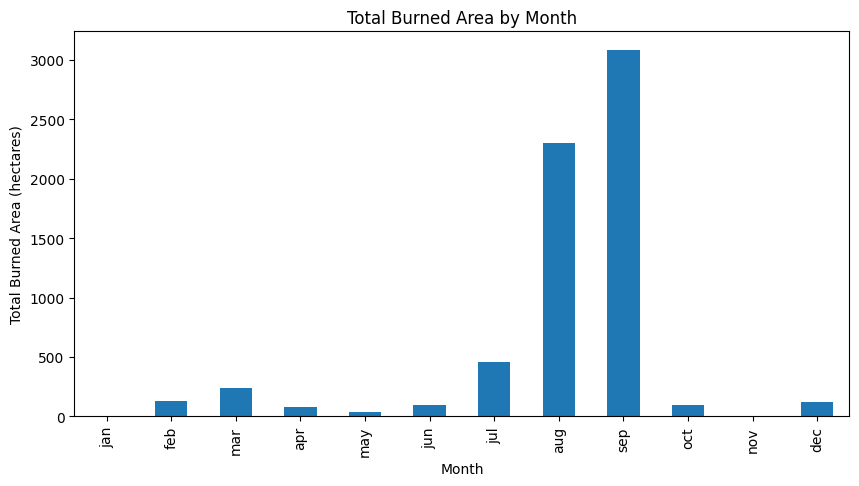

In [42]:
plt.figure(figsize=(10, 5))

monthly_area.plot(kind="bar")

plt.title("Total Burned Area by Month")
plt.xlabel("Month")
plt.ylabel("Total Burned Area (hectares)")

plt.show()

Most fires ≠ most burned area.

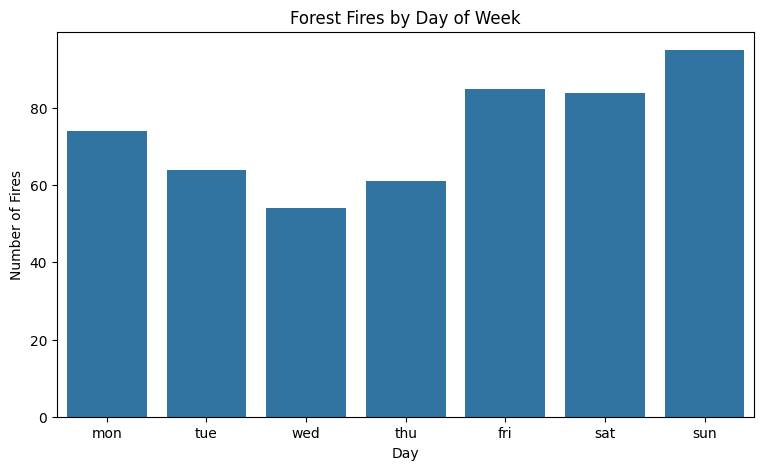

In [43]:
#Explore day of the week

day_order = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="day",
    order=day_order
)

plt.title("Forest Fires by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Fires")

plt.show()

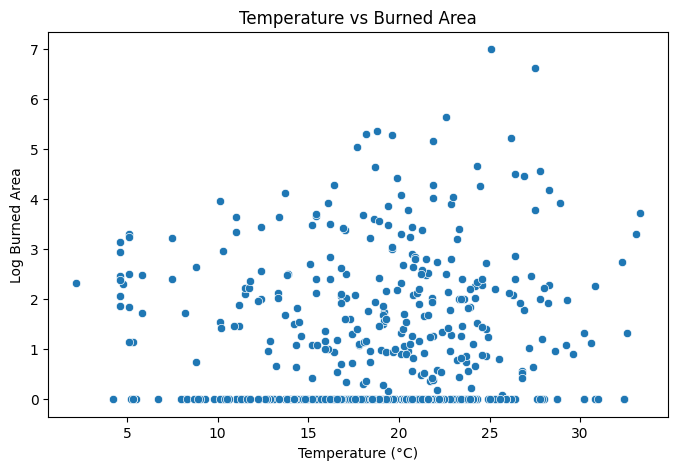

In [44]:
#Temperature vs burned area

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="temp",
    y="log_area"
)

plt.title("Temperature vs Burned Area")
plt.xlabel("Temperature (°C)")
plt.ylabel("Log Burned Area")

plt.show()

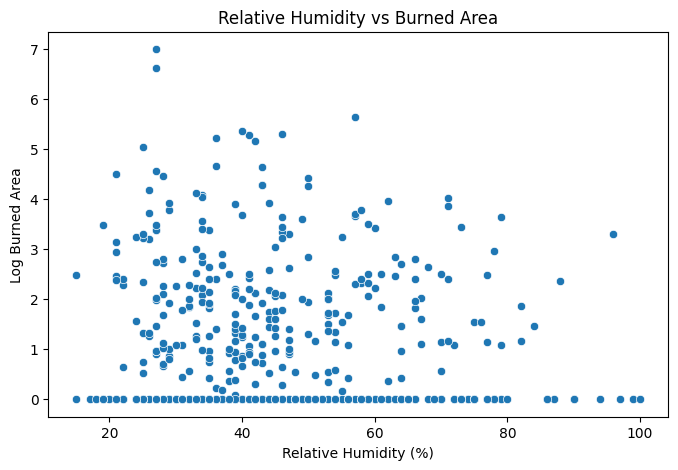

In [45]:
#Humidity vs burned area

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="RH",
    y="log_area"
)

plt.title("Relative Humidity vs Burned Area")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Log Burned Area")

plt.show()

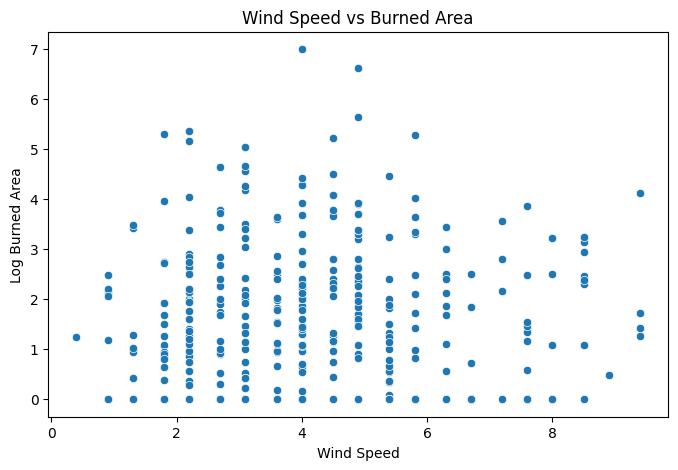

In [46]:
#Wind vs burned area

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="wind",
    y="log_area"
)

plt.title("Wind Speed vs Burned Area")
plt.xlabel("Wind Speed")
plt.ylabel("Log Burned Area")

plt.show()


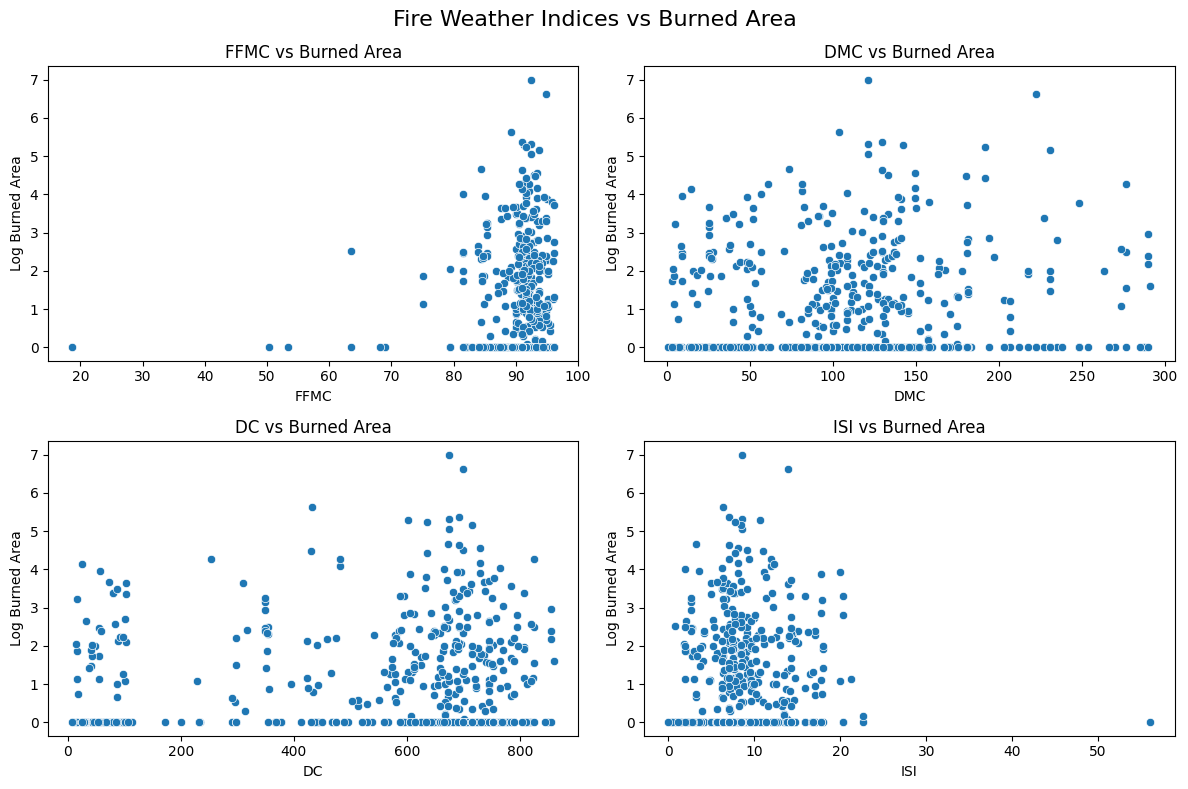

In [53]:
#Fire-weather indices vs burned area

## FFMC, DMC, DC, ISI vs Burned Area

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# FFMC
sns.scatterplot(
    data=df,
    x="FFMC",
    y="log_area",
    ax=axes[0, 0]
)
axes[0, 0].set_title("FFMC vs Burned Area")
axes[0, 0].set_xlabel("FFMC")
axes[0, 0].set_ylabel("Log Burned Area")

# DMC
sns.scatterplot(
    data=df,
    x="DMC",
    y="log_area",
    ax=axes[0, 1]
)
axes[0, 1].set_title("DMC vs Burned Area")
axes[0, 1].set_xlabel("DMC")
axes[0, 1].set_ylabel("Log Burned Area")

# DC
sns.scatterplot(
    data=df,
    x="DC",
    y="log_area",
    ax=axes[1, 0]
)
axes[1, 0].set_title("DC vs Burned Area")
axes[1, 0].set_xlabel("DC")
axes[1, 0].set_ylabel("Log Burned Area")

# ISI
sns.scatterplot(
    data=df,
    x="ISI",
    y="log_area",
    ax=axes[1, 1]
)
axes[1, 1].set_title("ISI vs Burned Area")
axes[1, 1].set_xlabel("ISI")
axes[1, 1].set_ylabel("Log Burned Area")

plt.suptitle("Fire Weather Indices vs Burned Area", fontsize=16)

plt.tight_layout()

plt.show()



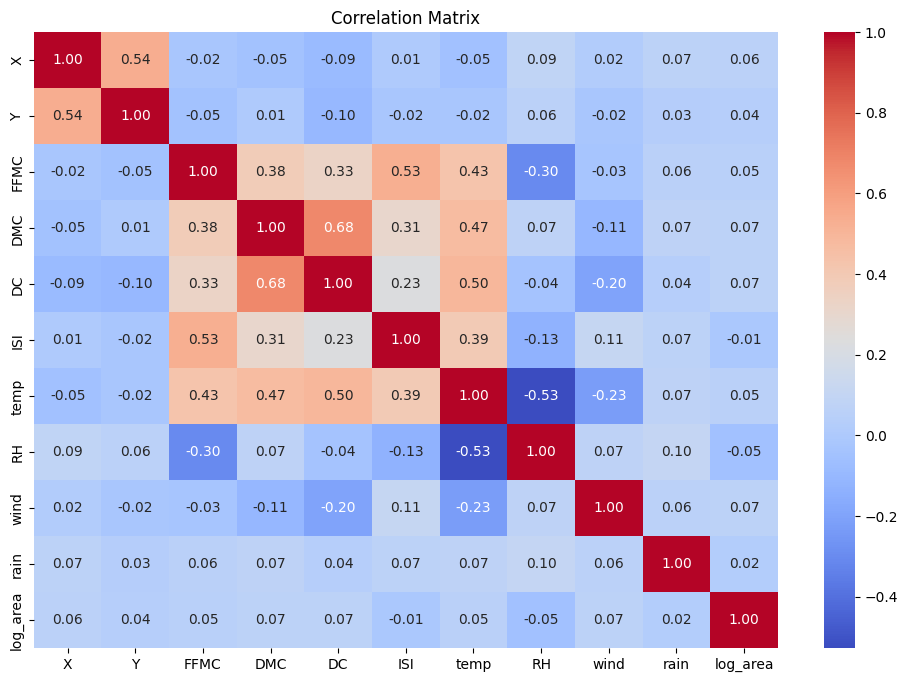

In [51]:
#Correlation matrix

corr_cols = [
    "X",
    "Y",
    "FFMC",
    "DMC",
    "DC",
    "ISI",
    "temp",
    "RH",
    "wind",
    "rain",
    "log_area"
]

correlation = df[corr_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

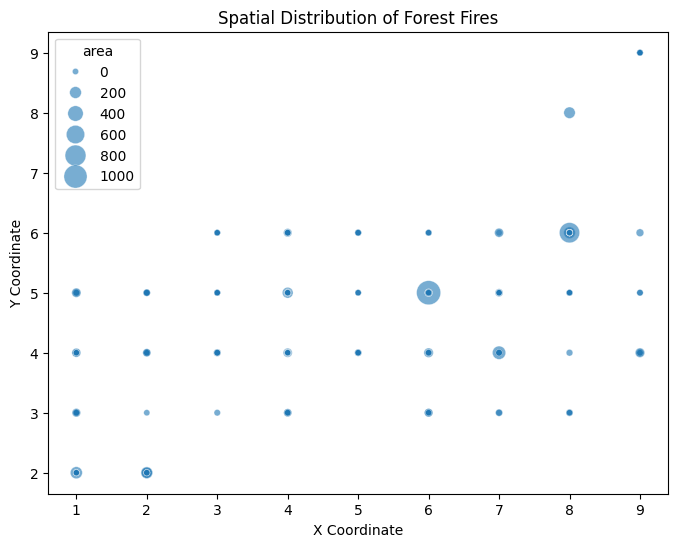

In [52]:
#Explore the X/Y locations

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="X",
    y="Y",
    size="area",
    sizes=(20, 300),
    alpha=0.6
)

plt.title("Spatial Distribution of Forest Fires")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")

plt.show()

# EDA Summary

The exploratory analysis showed that:

1. The burned-area target is highly right-skewed, with many small fires and a small number of very large fires.
2. A log transformation of burned area produces a more balanced target distribution for modeling.
3. Forest fire activity varies considerably by month.
4. The months with the highest number of fires are not necessarily the months with the greatest total burned area.
5. Weather variables and fire-weather indices show different distributions and relationships with fire severity.
6. Spatial coordinates suggest that fire activity is concentrated in particular areas of the park.
7. Further preprocessing is required before modeling, particularly encoding categorical variables such as month and day and scaling numerical features for clustering and certain regression models.